In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/parasharmanas/movie-recommendation-system/movies.csv
/kaggle/input/datasets/parasharmanas/movie-recommendation-system/ratings.csv


**The Following Models are used**
<br>
**1. Pure SVD - ** Rating= Xm*Xu
<br>
**2. Cosine Similarity - ** Sim[i][j]=sum(Ck*rkj) , Ck = sum(ri*rk)/product(mag(rk))*mag(ri)
<br>
**Now , hybrid SVD++ **
<br>
**3. SVD + Genre -**  Rating=(Xm+G)*Xu
<br>
**4. SVD+ user sim - ** Rating=Xm*(Xu+Sim)
<br>
**5. SVD + Genr + user sim -** Rating=(Xm+G)*(Xu+Sim)
<br>
**6. Ensemble -** rating = sum(beta_i*ri)/sum(beta_i) , where ,ri is it's predicted rating

In [2]:
movies = pd.read_csv(
    "/kaggle/input/datasets/parasharmanas/movie-recommendation-system/movies.csv"
)
ratings = pd.read_csv(
    "/kaggle/input/datasets/parasharmanas/movie-recommendation-system/ratings.csv"
)


In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [5]:
ratings.shape

(25000095, 4)

In [6]:
df = ratings[["userId", "movieId", "rating"]].head(200000)  #Taking only the top 20000 ratings

In [7]:

# --- Cold Start Prevention ---
# Retain users with >= 20 ratings and movies with >= 10 ratings
user_counts = df["userId"].value_counts()
movie_counts = df["movieId"].value_counts()

df = df[df["userId"].isin(user_counts[user_counts >= 20].index)]
df = df[df["movieId"].isin(movie_counts[movie_counts >= 10].index)]

print(f"Post-cleaning dataset size: {len(df)} rows")

Post-cleaning dataset size: 176053 rows


Data remaining after cleaning: 175482 rows


/tmp/ipykernel_16/1526892080.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


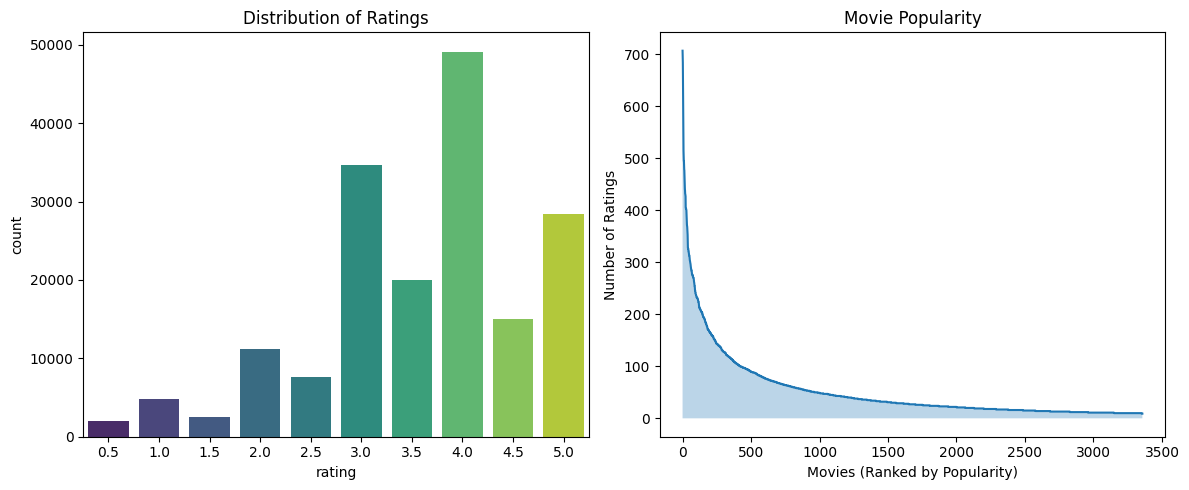

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# DATA CLEANING (Cold Start Prevention)
# Only keep users who have rated at least 20 movies and movies with at least 10 ratings
user_counts = df['userId'].value_counts()
movie_counts = df['movieId'].value_counts()

df = df[df['userId'].isin(user_counts[user_counts >= 20].index)]
df = df[df['movieId'].isin(movie_counts[movie_counts >= 10].index)]

print(f"Data remaining after cleaning: {len(df)} rows")

#DATA VISUALIZATION
plt.figure(figsize=(12, 5))

# Plot 1: Rating Distribution
plt.subplot(1, 2, 1)
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')

# Plot 2: Movie Popularity
plt.subplot(1, 2, 2)
movie_freq = df.groupby('movieId').size().sort_values(ascending=False)
plt.plot(range(len(movie_freq)), movie_freq.values)
plt.fill_between(range(len(movie_freq)), movie_freq.values, alpha=0.3)
plt.title('Movie Popularity')
plt.xlabel('Movies (Ranked by Popularity)')
plt.ylabel('Number of Ratings')

plt.tight_layout()
plt.show()

In [9]:
#Since all the data are not bieng taken into consideration , there is a high chance that the taken data has missing movie Id's so label encoding them
from sklearn.preprocessing import LabelEncoder
me = LabelEncoder()
ue = LabelEncoder()

In [10]:
#SPLITTING INTO TRAIN AND VALIDATION SET

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [11]:
#ENSURING , WE HAVE ONLY THOSE MOVIE IN VALIDATION , ON WHICH THE MODEL HAS TRAINED
train_movies = set(train_df["movieId"])
train_users = set(train_df["userId"])
val_df = val_df[
    val_df["movieId"].isin(train_movies) & val_df["userId"].isin(train_users)
]

In [12]:
# FITTING ENCODER ON TRAINING SET
movie_train = me.fit_transform(train_df["movieId"])
user_train = ue.fit_transform(train_df["userId"])
rating_train = train_df["rating"].values.astype(np.float32)

In [13]:
# FITTING ENCODER ON VALIDATION SET
movie_val = me.transform(val_df["movieId"])
user_val = ue.transform(val_df["userId"])
rating_val = val_df["rating"].values.astype(np.float32)

In [14]:
#NORMALIZING
r_min = rating_train.min()
r_max = rating_train.max()
 
rating_train_norm = (rating_train - r_min) / (r_max - r_min)

In [15]:
mu  = rating_train_norm.mean()               # mean

# MODEL 1 :  PURE SVD

In [16]:
n_movies = len(me.classes_)
n_users  = len(ue.classes_)
k1 = 20    # K IS THE NO. OF FEATURES TO BE CREATED


In [17]:
# INITIALIZING PARAMETERS
np.random.seed(42)
X_m1 = np.random.normal(0, 0.1, (n_movies, k1)).astype(np.float32) # MOVIE FEATURES
X_u1 = np.random.normal(0, 0.1, (n_users,  k1)).astype(np.float32) # USER FEATURES
 
print(f"Movies: {n_movies} | Users: {n_users} | k1: {k1}")
print(f"Train: {len(rating_train)} | Test: {len(rating_val)}")

Movies: 3358 | Users: 1376 | k1: 20
Train: 140385 | Test: 35097


In [18]:
# INITIALING BIASES
b_m1 = np.zeros(n_movies, dtype=np.float32)  # movie bias
b_u1 = np.zeros(n_users,  dtype=np.float32)  # user bias


# MODEL 2 : COSINE SIMILARITY

In [19]:
#CREATING A DICTIONARY OF THE FORMAT {USERID :{MOVIEID:RATING}} , THIS PREVENTS THE PROBLEM OF SPARSE MATRIX
from collections import defaultdict
# USING LIBRARY FUNCTION TO AVIOD KEY ERROR-PROBLEM
user_movie_ratings = defaultdict(dict)
for u, m, r in zip(user_train, movie_train, rating_train):
    user_movie_ratings[u][m] = r

In [20]:
def cosine_similarity(u1, u2):
    movies_u1 = set(user_movie_ratings[u1].keys())
    movies_u2 = set(user_movie_ratings[u2].keys())
    common = movies_u1 & movies_u2

    if len(common) == 0:
        return 0

    dot = sum(user_movie_ratings[u1][m] * user_movie_ratings[u2][m] for m in common)
    mag1 = np.sqrt(sum(user_movie_ratings[u1][m] ** 2 for m in common))
    mag2 = np.sqrt(sum(user_movie_ratings[u2][m] ** 2 for m in common))

    return dot / (mag1 * mag2 + 1e-8) if (mag1 * mag2) != 0 else 0

In [21]:
#CREATING SIMILARITY MATRIX
sim_matrix = np.zeros((n_users, n_users), dtype=np.float32)

for i in range(n_users):
    sim_matrix[i][i] = 1.0  # A user is 100% similar to themselves
    for j in range(i + 1, n_users):
        sim = cosine_similarity(i, j)
        sim_matrix[i][j] = sim
        sim_matrix[j][i] = sim  # If User A is like B, then B is like A

In [22]:
# NOW , Say , we want to predict for user i and movie j , so we will need to know all the users who rated movie j
# movie_raters={movieId:[(userId,rating)]}
movie_raters = defaultdict(list)
for u in range(n_users):
    for m, rating in user_movie_ratings[u].items():
        movie_raters[m].append((u, rating))

In [23]:
def get_sim_pred(user, movie):
    #This function calulates predicted rating= sum_k_(Sim_matrix[i][k]*rating)/sum_k_(sim_matrix[i][k])
    raters = movie_raters[movie]
    if len(raters) == 0:
        return rating_train.mean()

    scored = []
    for r_user, rating in raters:
        if r_user == user:
            continue
        sim = sim_matrix[user][r_user]
        if sim > 0:
            scored.append((sim, rating))

    # Taking top 20 most similar
    scored = sorted(scored, key=lambda x: x[0], reverse=True)[:20]

    tot_rating = 0.0
    tot_sim = 0.0
    for sim, rating in scored:
        tot_rating += sim * rating
        tot_sim += sim

    return tot_rating / tot_sim if tot_sim > 0 else rating_train.mean()


In [24]:
# MAKING PREDICTIONS
train_sim_preds = np.array(
    [get_sim_pred(user_train[i], movie_train[i]) for i in range(len(rating_train))]
)
train_sim_preds_norm = (train_sim_preds - r_min) / (r_max - r_min)

val_sim_preds = np.array(
    [get_sim_pred(user_val[i], movie_val[i]) for i in range(len(rating_val))]
)
val_sim_preds_norm = (val_sim_preds - r_min) / (r_max - r_min)

# MODEL 3 : SVD WITH MOVIE GENRE

In [25]:
# CREATING MOVIES_DF WHICH INCLUDES ONLY THOSE MOVIES WHICH ARE IN DF
movies_df = movies[movies['movieId'].isin(me.classes_)]

In [26]:
all_genres = set()  # USING SET() TO ENSURE WE DON'T HAVE REPEATED ELEMENTS
for g_str in movies_df['genres']:
    all_genres.update(g_str.split('|'))

genre_list = sorted(list(all_genres))
ge = LabelEncoder().fit(genre_list)

In [27]:
n_genres = len(ge.classes_)

In [28]:
movie_to_genres = defaultdict(list)
for _, row in movies_df.iterrows():
    m_id = row['movieId']
    m_enc = me.transform([m_id])[0]
    g_indices = ge.transform(row['genres'].split('|'))
    movie_to_genres[m_enc] = g_indices

In [29]:
k3 = 20  # latent features

In [30]:
#INITIALIZING PARAMETERS
X_g = np.random.normal(0, 0.1, (n_genres, k3)).astype(np.float32)  # Each genre gets its own latent features
X_m3 = np.random.normal(0, 0.1, (n_movies, k3)).astype(np.float32)
X_u3 = np.random.normal(0, 0.1, (n_users, k3)).astype(np.float32)
b_m3 = np.zeros(n_movies, dtype=np.float32)
b_u3 = np.zeros(n_users, dtype=np.float32)

# MODEL 4 : SVD + USER SIMILARITY

In [31]:
k4=20

In [32]:
# ── FAST SIMILARITY VECTOR RETRIEVAL ───────
def get_sim_vector(user, movie, X_u_matrix,k):
    raters = movie_raters[movie]
    if len(raters) == 0:
        return np.zeros(k, dtype=np.float32)

    scored = []
    for r_user, rating in raters:
        if r_user == user:
            continue
        sim = sim_matrix[user][r_user]
        if sim > 0:
            scored.append((sim, r_user))

    scored = sorted(scored, key=lambda x: x[0], reverse=True)[:20]

    sim_vec = np.zeros(k, dtype=np.float32)
    tot = 0.0
    for sim, r_user in scored:
        sim_vec += sim * X_u_matrix[r_user]
        tot += sim

    return sim_vec / tot if tot > 0 else np.zeros(k, dtype=np.float32)

In [33]:
X_m4 = np.random.normal(0, 0.1, (n_movies, k4)).astype(np.float32)
X_u4 = np.random.normal(0, 0.1, (n_users, k4)).astype(np.float32)
b_m4 = np.zeros(n_movies, dtype=np.float32)
b_u4 = np.zeros(n_users, dtype=np.float32)

# MODEL 5 : SVD + Genre + User Similarity

In [34]:
k5=20

In [35]:
X_g5= np.random.normal(0, 0.1, (n_genres, k5)).astype(np.float32)
X_m5 = np.random.normal(0, 0.1, (n_movies, k5)).astype(np.float32)
X_u5 = np.random.normal(0, 0.1, (n_users, k5)).astype(np.float32)
b_m5 = np.zeros(n_movies, dtype=np.float32)
b_u5 = np.zeros(n_users, dtype=np.float32)

# MODEL 6 : ENSEMBLE

In [36]:
#Initializing parameters
# pred=sum(beta_i * predi)/sum(beta_i)
beta_1=0.981
beta_2=0.011
beta_3=1.097
beta_4=1.120
beta_5=1.259

# Pre-Calculating user similarities

In [37]:
# Create a new cell right before your training loop cell
sim_raters_cache = {}

def precalculate_top20(user, movie):
    if (user, movie) in sim_raters_cache: 
        return
    raters = movie_raters.get(movie, [])
    scored = []
    for r_user, _ in raters:
        if r_user == user: 
            continue
        sim = sim_matrix[user][r_user]
        if sim > 0: 
            scored.append((sim, r_user))
            
    scored = sorted(scored, key=lambda x: x[0], reverse=True)[:20]
    tot_sim = sum(s for s, _ in scored)
    sim_raters_cache[(user, movie)] = (scored, tot_sim)

# Run the pre-calculations
print("Caching training similarities...")
for idx in range(len(rating_train)): 
    precalculate_top20(user_train[idx], movie_train[idx])

print("Caching validation similarities...")
for idx in range(len(rating_val)): 
    precalculate_top20(user_val[idx], movie_val[idx])

print("Caching complete!")

Caching training similarities...
Caching validation similarities...
Caching complete!


# PREDICTING RATINGS FOR A GIVEN USER , MOVIE

In [38]:
def prediction(movie_idx, user_idx, model_type,val=False,fallback_idx=None):
    i = movie_idx
    j = user_idx

    # Model 1 : Pure SVD
    if model_type == 1:
        pred=np.dot(X_m1[i],X_u1[j]) + b_m1[i] + b_u1[j] + mu

    # Model 2 : Cosine Similarity
    elif model_type == 2: 
        if val == False and fallback_idx is not None and fallback_idx < len(train_sim_preds_norm):
            pred = train_sim_preds_norm[fallback_idx] 
        elif val == True and fallback_idx is not None and fallback_idx < len(val_sim_preds_norm):
            pred = val_sim_preds_norm[fallback_idx]
        else:
            # INFERENCE MODE: Calculate on the fly for unseen pairs
            raw_sim = get_sim_pred(j, i) # j is user, i is movie
            pred = (raw_sim - r_min) / (r_max - r_min)
    # Model 3 : SVD+GENRE
    elif model_type == 3:
        g_indices = movie_to_genres[i]
        genre_sum = np.zeros(k3, dtype=np.float32)
        if len(g_indices) > 0:
            genre_sum = np.sum(X_g[g_indices], axis=0)/ len(g_indices)
        
        m_vec3 = X_m3[i] + genre_sum
        pred = np.dot(m_vec3, X_u3[j]) + b_m3[i] + b_u3[j] + mu

    # Model 4 : SVD + User similarity
    elif model_type == 4:
        # Fast cache extraction
        scored, tot = sim_raters_cache.get((j, i), ([], 0.0))
        sim_vec4 = sum(sim * X_u4[r_user] for sim, r_user in scored) / tot if tot > 0 else np.zeros(k4, dtype=np.float32)
        u_vec4 = X_u4[j] + sim_vec4
        pred = np.dot(X_m4[i], u_vec4) + b_m4[i] + b_u4[j] + mu

    # MODEL 5 : SVD + Genre + User Similarity
    elif model_type == 5:
        g_indices = movie_to_genres[i]
        genre_sum5 = np.zeros(k5, dtype=np.float32)
        
        if len(g_indices) > 0:
            genre_sum5 = np.sum(X_g5[g_indices], axis=0)/ len(g_indices)
        
        m_vec5 = X_m5[i] + genre_sum5

        # Fast cache extraction
        scored, tot = sim_raters_cache.get((j, i), ([], 0.0))
        sim_vec5 = sum(sim * X_u5[r_user] for sim, r_user in scored) / tot if tot > 0 else np.zeros(k5, dtype=np.float32)
        u_vec5 = X_u5[j] + sim_vec5

        pred = np.dot(m_vec5 , u_vec5) + b_m5[i] + b_u5[j] + mu
        
    # MODEL 6 : ENSEMBLE
    elif model_type == 6:
        # Model 1
        pred1=np.dot(X_m1[i],X_u1[j]) + b_m1[i] + b_u1[j] + mu

        # Model 2
        if val == False and fallback_idx is not None and fallback_idx < len(train_sim_preds_norm):
            pred2 = train_sim_preds_norm[fallback_idx] 
        elif val == True and fallback_idx is not None and fallback_idx < len(val_sim_preds_norm):
            pred2 = val_sim_preds_norm[fallback_idx]
        else:
            # INFERENCE MODE: Calculate on the fly for unseen pairs
            raw_sim = get_sim_pred(j, i) # j is user, i is movie
            pred2 = (raw_sim - r_min) / (r_max - r_min)
        # Model 3
        g_indices = movie_to_genres[i]
        genre_sum3 = np.zeros(k3, dtype=np.float32)
        if len(g_indices) > 0:
            genre_sum3 = np.sum(X_g[g_indices], axis=0)/ len(g_indices)
        
        m_vec3 = X_m3[i] + genre_sum3
        pred3 = np.dot(m_vec3, X_u3[j]) + b_m3[i] + b_u3[j] + mu

        # Model 4
        sim_vec4 = get_sim_vector(j, i, X_u4,k4)
        u_vec4 = X_u4[j] + sim_vec4
        pred4 = np.dot(X_m4[i], u_vec4) + b_m4[i] + b_u4[j] + mu

        # Model 5
        g_indices = movie_to_genres[i]
        genre_sum5 = np.zeros(k5, dtype=np.float32)
        
        if len(g_indices) > 0:
            genre_sum5 = np.sum(X_g5[g_indices], axis=0)/ len(g_indices)

        m_vec5 = X_m5[i] + genre_sum5

        sim_vec5 = get_sim_vector(j, i, X_u5,k5)
        u_vec5 = X_u5[j] + sim_vec5

        pred5 = np.dot(m_vec5 , u_vec5) + b_m5[i] + b_u5[j] + mu


        # Model 6
        pred=(beta_1*pred1 + beta_2*pred2 + beta_3*pred3 + beta_4*pred4 + beta_5*pred5)/(beta_1 + beta_2 + beta_3 + beta_4 + beta_5)


            

    return pred
        

# EVALUATION

In [39]:
def evaluate_model(movie_idx, user_idx, rating_vals, model_type, val=False, sample_indices=None):
    preds = []
    for idx in range(len(rating_vals)):
        i = movie_idx[idx]
        j = user_idx[idx]
        # Use actual index into precomputed sim array
        sim_idx = sample_indices[idx] if sample_indices is not None else idx
        pred = prediction(i, j, model_type, val, fallback_idx=sim_idx)
        preds.append(pred)

    pred_norm = np.array(preds, dtype=np.float32)
    pred_denorm = pred_norm * (r_max - r_min) + r_min
    pred_denorm = np.clip(pred_denorm, r_min, r_max)

    rmse = np.sqrt(np.mean((rating_vals - pred_denorm) ** 2))

    return rmse

In [40]:
def get_precision_recall_at_k(test_data,model_type, k=10, threshold=4.0):
    user_est_true = defaultdict(list)
    
    # Predict for each item in validation set
    for u, m, actual in test_data:
        est = evaluate_model(np.array([m]), np.array([u]), np.array([actual]), model_type)
        user_est_true[u].append((est, actual))

    precisions = {}
    recalls = {}

    for u, user_ratings in user_est_true.items():
        # Sort by predicted rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (est, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, true_r) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])

        precisions[u] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[u] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return np.mean(list(precisions.values())), np.mean(list(recalls.values()))



In [41]:
def dcg_at_k(r, k):
    r = np.asfarray(r)[:k]
    if r.size:
        return np.sum(r / np.log2(np.arange(2, r.size + 2)))
    return 0.

def ndcg_at_k(test_data, k=10):
    user_est_true = defaultdict(list)
    for u, m, actual in test_data:
        # Use Model 6 (Ensemble) or loop through all models to compare
        est = evaluate_model(np.array([m]), np.array([u]), np.array([0]), model_type=6)
        user_est_true[u].append((est, actual))
    
    ndcgs = []
    for u, user_ratings in user_est_true.items():
        # Sort by predicted rating to get the model's ranking
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        predicted_relevance = [true_r for (est, true_r) in user_ratings]
        
        # Sort by actual rating to get the "ideal" ranking
        ideal_relevance = sorted(predicted_relevance, reverse=True)
        
        idcg = dcg_at_k(ideal_relevance, k)
        dcg = dcg_at_k(predicted_relevance, k)
        
        if idcg > 0:
            ndcgs.append(dcg / idcg)
            
    return np.mean(ndcgs)

# Training

In [42]:
def write_matrix(f, name, arr):
    if arr is not None:
        f.write(f"### {name}\n```python\n")
        f.write(f"{name} = np.array(")
        # We use a loop-based string conversion if the matrix is gargantuan, 
        # but np.array2string with threshold=np.inf is usually okay for RAM if written immediately.
        f.write(np.array2string(arr, threshold=np.inf, separator=', '))
        f.write(")\n```\n\n")

In [43]:
alpha1 = 0.005  # learning rate
lbda1 = 0.03  # regularization

alpha3 = 0.005  # learning rate
lbda3 = 0.03  # regularization

alpha4 = 0.005  # learning rate
lbda4 = 0.03  # regularization

alpha5 = 0.005  # learning rate
lbda5 = 0.03  # regularization

alpha6 = 0.005  # learning rate
lbda6 = 0.03  # regularization


In [44]:
epochs =150

In [45]:
# Model 1 : SVD
t_rmse1=[]
v_rmse1=[]
min_rmse=np.inf
last_5=np.full(5,100)
patience_counter=0
for epoch in range(epochs):
    idx_order = np.random.permutation(len(rating_train_norm))
    
    print(f'Epoch : {epoch}')
    for idx in idx_order:
        i = movie_train[idx]
        j = user_train[idx]
        r = rating_train_norm[idx]
        pred1 = prediction(i, j, model_type=1,val=False)
        err1 = pred1 - r

        X_m1_old = X_m1[i].copy()
        X_m1[i] -= alpha1 * (err1 * X_u1[j] + lbda1 * X_m1[i])
        X_u1[j] -= alpha1 * (err1 * X_m1_old + lbda1 * X_u1[j])
        b_m1[i] -= alpha1 * (err1 +lbda1*b_m1[i])
        b_u1[j] -= alpha1 * (err1 +lbda1*b_u1[j])

    sample_idx = np.random.choice(len(rating_train),10000, replace=False)
    t_rmse = evaluate_model(movie_train[sample_idx], user_train[sample_idx], rating_train[sample_idx],1,sample_indices=sample_idx)  # pass actual indices
    v_rmse = evaluate_model(movie_val, user_val, rating_val, 1 , val=True)
    t_rmse1.append(t_rmse)
    v_rmse1.append(v_rmse)
    print(f'Model 1 : SVD | Train RMSE : {t_rmse} | Val RMSE : {v_rmse}')

    #Early stopping
    if v_rmse < min_rmse:
        min_rmse = v_rmse
        patience_counter = 0
        best_X_u1 = X_u1.copy()
        best_X_m1 = X_m1.copy()
        best_b_u1 = b_u1.copy()
        best_b_m1 = b_m1.copy()
    else:
        patience_counter += 1
        
    if patience_counter >= 5: # Stop if no improvement for 3 epochs
        print("Early stopping triggered.")
        break    
    if epoch > 0 and v_rmse > v_rmse1[-2]-(1e-4):  # val got worse
        alpha1 *= 0.98 
    if epoch > 0 and v_rmse-t_rmse > v_rmse1[-2]-t_rmse1[-2]:
        lbda1 *=1.02
    

Epoch : 0
Model 1 : SVD | Train RMSE : 0.921045184135437 | Val RMSE : 0.9409525394439697
Epoch : 1
Model 1 : SVD | Train RMSE : 0.8924076557159424 | Val RMSE : 0.9158339500427246
Epoch : 2
Model 1 : SVD | Train RMSE : 0.8762561678886414 | Val RMSE : 0.9035739302635193
Epoch : 3
Model 1 : SVD | Train RMSE : 0.8699290156364441 | Val RMSE : 0.8960440158843994
Epoch : 4
Model 1 : SVD | Train RMSE : 0.8605009913444519 | Val RMSE : 0.8905392289161682
Epoch : 5
Model 1 : SVD | Train RMSE : 0.8528412580490112 | Val RMSE : 0.8864818215370178
Epoch : 6
Model 1 : SVD | Train RMSE : 0.8483349680900574 | Val RMSE : 0.8832125663757324
Epoch : 7
Model 1 : SVD | Train RMSE : 0.8357878923416138 | Val RMSE : 0.8805288672447205
Epoch : 8
Model 1 : SVD | Train RMSE : 0.8405040502548218 | Val RMSE : 0.8787698745727539
Epoch : 9
Model 1 : SVD | Train RMSE : 0.8361961245536804 | Val RMSE : 0.8770211935043335
Epoch : 10
Model 1 : SVD | Train RMSE : 0.8414739966392517 | Val RMSE : 0.8754251599311829
Epoch : 11

In [46]:
from datetime import datetime
with open("try.md", "w") as f:
    # --- Header ---
    f.write(f"# Final 6-Model Recommender Report\n**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")

    # --- Model 1 ---
    print("Writing Model 1...")
    f.write(f"## Model 1: Pure SVD\n- Alpha: {alpha1}\n- Lambda: {lbda1}\n")
    f.write(f"- Train RMSE: {t_rmse1[-1]:.4f} | Val RMSE: {v_rmse1[-1]:.4f}\n\n")
    write_matrix(f, "X_u1", best_X_u1)
    write_matrix(f, "X_m1", best_X_m1)
    f.write("---\n")

Writing Model 1...


In [47]:
# Model 2 : Cosine Similarity
t_rmse2=[]
v_rmse2=[]
min_rmse_2=np.inf
last_5_2=np.full(5,100)

sample_idx = np.random.choice(len(rating_train),10000, replace=False)
t_rmse = evaluate_model(movie_train[sample_idx], user_train[sample_idx], rating_train[sample_idx],2,sample_indices=sample_idx)  # pass actual indices
v_rmse = evaluate_model(movie_val, user_val, rating_val, 2 , val=True)
t_rmse2.append(t_rmse)
v_rmse2.append(v_rmse)
print(f'Model 2 : Cosine Similarity | Train RMSE : {t_rmse} | Val RMSE : {v_rmse}')



Model 2 : Cosine Similarity | Train RMSE : 0.8958212733268738 | Val RMSE : 0.9743532538414001


In [48]:
with open("try.md", "w") as f:
    # --- Header ---
    f.write(f"# Final 6-Model Recommender Report\n**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")

    # --- Model 1 ---
    print("Writing Model 1...")
    f.write(f"## Model 1: Pure SVD\n- Alpha: {alpha1}\n- Lambda: {lbda1}\n")
    f.write(f"- Train RMSE: {t_rmse1[-1]:.4f} | Val RMSE: {v_rmse1[-1]:.4f}\n\n")
    write_matrix(f, "X_u1", best_X_u1)
    write_matrix(f, "X_m1", best_X_m1)
    f.write("---\n")

    # --- Model 2 ---
    print("Writing Model 2...")
    f.write(f"## Model 2: Cosine Similarity\n- Train RMSE: {t_rmse2[-1]:.4f} | Val RMSE: {v_rmse2[-1]:.4f}\n\n---\n")


Writing Model 1...
Writing Model 2...


In [49]:
# Model 3 : SVD + Genre
t_rmse3=[]
v_rmse3=[]
min_rmse_3=np.inf
last_5_3=np.full(5,100)
patience_counter = 0
for epoch in range(epochs):
    idx_order = np.random.permutation(len(rating_train_norm))
    
    print(f'Epoch : {epoch}\n')
    for idx in idx_order:
        i = movie_train[idx]
        j = user_train[idx]
        r = rating_train_norm[idx]
        
        pred3 = prediction(i, j, model_type=3,val=False)
        err3 = pred3 - r

        g_indices = movie_to_genres[i]
        genre_sum3 = np.zeros(k3, dtype=np.float32)
        if len(g_indices) > 0:
            genre_sum3 = np.sum(X_g[g_indices], axis=0)/len(g_indices)
        m_vec3 = X_m3[i] + genre_sum3
        X_u3_old = X_u3[j].copy()
        X_m3_old = X_m3[i].copy()
    
        X_u3[j] -= alpha3 * (err3 * m_vec3 + lbda3 * X_u3[j])
        X_m3[i] -= alpha3 * (err3 * X_u3_old + lbda3 * X_m3[i])
        b_m3[i] -= alpha3 *(err3 +lbda3*b_m3[i])
        b_u3[j] -= alpha3 * (err3 +lbda3*b_u3[j])

        if len(g_indices) > 0:
            for g_idx in g_indices:
                X_g[g_idx] -= alpha3 * (err3 * X_u3_old + lbda3 * X_g[g_idx])

        
    sample_idx = np.random.choice(len(rating_train),10000, replace=False)
    t_rmse = evaluate_model(movie_train[sample_idx], user_train[sample_idx], rating_train[sample_idx],3,sample_indices=sample_idx)  # pass actual indices
    v_rmse = evaluate_model(movie_val, user_val, rating_val, 3 , val=True)
    t_rmse3.append(t_rmse)
    v_rmse3.append(v_rmse)
    print(f'Model 3 : SVD + Genre | Train RMSE : {t_rmse} | Val RMSE : {v_rmse}')

    #Early stopping
    if v_rmse < min_rmse_3:
        min_rmse_3 = v_rmse
        patience_counter = 0
        best_X_u3 = X_u3.copy()
        best_X_m3 = X_m3.copy()
        best_b_u3 = b_u3.copy()
        best_b_m3 = b_m3.copy()
        best_X_g = X_g.copy()
    else:
        patience_counter += 1
        
    if patience_counter >= 5: # Stop if no improvement for 3 epochs
        print("Early stopping triggered.")
        break 
    if v_rmse-t_rmse>0.15:
        break
    if epoch > 0 and v_rmse > v_rmse3[-2]-(1e-4):  # val got worse
        alpha3 *= 0.98 
    if epoch > 0 and v_rmse-t_rmse > v_rmse3[-2]-t_rmse3[-2]:
        lbda3 *=1.02


Epoch : 0

Model 3 : SVD + Genre | Train RMSE : 0.9230939745903015 | Val RMSE : 0.9410412907600403
Epoch : 1

Model 3 : SVD + Genre | Train RMSE : 0.892573356628418 | Val RMSE : 0.9158322811126709
Epoch : 2

Model 3 : SVD + Genre | Train RMSE : 0.8854139447212219 | Val RMSE : 0.9033672213554382
Epoch : 3

Model 3 : SVD + Genre | Train RMSE : 0.875806450843811 | Val RMSE : 0.8955680727958679
Epoch : 4

Model 3 : SVD + Genre | Train RMSE : 0.8641834855079651 | Val RMSE : 0.8899334073066711
Epoch : 5

Model 3 : SVD + Genre | Train RMSE : 0.8578079342842102 | Val RMSE : 0.8860443234443665
Epoch : 6

Model 3 : SVD + Genre | Train RMSE : 0.8485578894615173 | Val RMSE : 0.8828980326652527
Epoch : 7

Model 3 : SVD + Genre | Train RMSE : 0.8339776992797852 | Val RMSE : 0.880001425743103
Epoch : 8

Model 3 : SVD + Genre | Train RMSE : 0.8425804972648621 | Val RMSE : 0.8780755400657654
Epoch : 9

Model 3 : SVD + Genre | Train RMSE : 0.8491125702857971 | Val RMSE : 0.8762275576591492
Epoch : 10

M

In [50]:
with open("try.md", "w") as f:
    # --- Header ---
    f.write(f"# Final 6-Model Recommender Report\n**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")

    # --- Model 1 ---
    print("Writing Model 1...")
    f.write(f"## Model 1: Pure SVD\n- Alpha: {alpha1}\n- Lambda: {lbda1}\n")
    f.write(f"- Train RMSE: {t_rmse1[-1]:.4f} | Val RMSE: {v_rmse1[-1]:.4f}\n\n")
    write_matrix(f, "X_u1", best_X_u1)
    write_matrix(f, "X_m1", best_X_m1)
    
    f.write("---\n")

    # --- Model 2 ---
    print("Writing Model 2...")
    f.write(f"## Model 2: Cosine Similarity\n- Train RMSE: {t_rmse2[-1]:.4f} | Val RMSE: {v_rmse2[-1]:.4f}\n\n---\n")

    # --- Model 3 ---
    print("Writing Model 3...")
    f.write(f"## Model 3: SVD + Genre\n- Alpha: {alpha3}\n- Lambda: {lbda3}\n")
    f.write(f"- Train RMSE: {t_rmse3[-1]:.4f} | Val RMSE: {v_rmse3[-1]:.4f}\n\n")
    write_matrix(f, "X_u3", best_X_u3)
    write_matrix(f, "X_m3", best_X_m3)
    write_matrix(f, "X_g3", best_X_g)
    f.write("---\n")

Writing Model 1...
Writing Model 2...
Writing Model 3...


In [51]:
# Model 4 : SVD + Cosine Similarity
t_rmse4=[]
v_rmse4=[]
min_rmse_4=np.inf
last_5_4=np.full(5,100)
patience_counter = 0
count=0
for epoch in range(epochs):
    idx_order = np.random.permutation(len(rating_train_norm))
    
    print(f'Epoch : {epoch}\n')
    for idx in idx_order:
        i = movie_train[idx]
        j = user_train[idx]
        r = rating_train_norm[idx]
        
        pred4 = prediction(i, j, model_type=4,val=False)
        err4 = pred4 - r

        # Replaced with Cache
        scored, tot = sim_raters_cache.get((j, i), ([], 0.0))
        sim_vec4 = sum(sim * X_u4[r_user] for sim, r_user in scored) / tot if tot > 0 else np.zeros(k4, dtype=np.float32)
        u_vec4 = X_u4[j] + sim_vec4
        X_m4_old = X_m4[i].copy()
        X_m4[i] -= alpha4 * (err4 * u_vec4 + lbda4 * X_m4[i])
        X_u4[j] -= alpha4 * (err4 * X_m4_old + lbda4 * X_u4[j])
        b_m4[i] -= alpha4 * (err4 +lbda4*b_m4[i])
        b_u4[j] -= alpha4 * (err4 +lbda4*b_u4[j])
        
    sample_idx = np.random.choice(len(rating_train),10000, replace=False)
    t_rmse = evaluate_model(movie_train[sample_idx], user_train[sample_idx], rating_train[sample_idx],4,sample_indices=sample_idx)  # pass actual indices
    v_rmse = evaluate_model(movie_val, user_val, rating_val, 4 , val=True)
    t_rmse4.append(t_rmse)
    v_rmse4.append(v_rmse)
    print(f'Model 4 : SVD + Cos Sim | Train RMSE : {t_rmse} | Val RMSE : {v_rmse}')

    #Early stopping
    if v_rmse < min_rmse_4:
        min_rmse_4 = v_rmse
        patience_counter = 0
        best_X_u4 = X_u4.copy()
        best_X_m4 = X_m4.copy()
        best_b_u4 = b_u4.copy()
        best_b_m4 = b_m4.copy()
    else:
        patience_counter += 1
        
    if patience_counter >= 5: # Stop if no improvement for 3 epochs
        print("Early stopping triggered.")
        break 
    if v_rmse-t_rmse>0.15:
        break
    if epoch > 0 and v_rmse > v_rmse4[-2]-(1e-4):  # val got worse
        alpha4 *= 0.98 
    if epoch > 0 and v_rmse-t_rmse > v_rmse4[-2]-t_rmse4[-2]:
        lbda4 *=1.02


Epoch : 0

Model 4 : SVD + Cos Sim | Train RMSE : 0.9184083938598633 | Val RMSE : 0.9440425634384155
Epoch : 1

Model 4 : SVD + Cos Sim | Train RMSE : 0.8892011046409607 | Val RMSE : 0.9181742072105408
Epoch : 2

Model 4 : SVD + Cos Sim | Train RMSE : 0.8810807466506958 | Val RMSE : 0.9053173065185547
Epoch : 3

Model 4 : SVD + Cos Sim | Train RMSE : 0.859401524066925 | Val RMSE : 0.8972771763801575
Epoch : 4

Model 4 : SVD + Cos Sim | Train RMSE : 0.8553900122642517 | Val RMSE : 0.891473650932312
Epoch : 5

Model 4 : SVD + Cos Sim | Train RMSE : 0.8523193001747131 | Val RMSE : 0.8876224756240845
Epoch : 6

Model 4 : SVD + Cos Sim | Train RMSE : 0.8486394286155701 | Val RMSE : 0.8842024803161621
Epoch : 7

Model 4 : SVD + Cos Sim | Train RMSE : 0.8304896354675293 | Val RMSE : 0.8816305994987488
Epoch : 8

Model 4 : SVD + Cos Sim | Train RMSE : 0.8305487036705017 | Val RMSE : 0.879348635673523
Epoch : 9

Model 4 : SVD + Cos Sim | Train RMSE : 0.8306559324264526 | Val RMSE : 0.8778978586

In [52]:
with open("try.md", "w") as f:
    # --- Header ---
    f.write(f"# Final 6-Model Recommender Report\n**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")

    # --- Model 1 ---
    print("Writing Model 1...")
    f.write(f"## Model 1: Pure SVD\n- Alpha: {alpha1}\n- Lambda: {lbda1}\n")
    f.write(f"- Train RMSE: {t_rmse1[-1]:.4f} | Val RMSE: {v_rmse1[-1]:.4f}\n\n")
    write_matrix(f, "X_u1", best_X_u1)
    write_matrix(f, "X_m1", best_X_m1)
    f.write("---\n")

    # --- Model 2 ---
    print("Writing Model 2...")
    f.write(f"## Model 2: Cosine Similarity\n- Train RMSE: {t_rmse2[-1]:.4f} | Val RMSE: {v_rmse2[-1]:.4f}\n\n---\n")

    # --- Model 3 ---
    print("Writing Model 3...")
    f.write(f"## Model 3: SVD + Genre\n- Alpha: {alpha3}\n- Lambda: {lbda3}\n")
    f.write(f"- Train RMSE: {t_rmse3[-1]:.4f} | Val RMSE: {v_rmse3[-1]:.4f}\n\n")
    write_matrix(f, "X_u3", best_X_u3)
    write_matrix(f, "X_m3", best_X_m3)
    write_matrix(f, "X_g3", best_X_g)
    f.write("---\n")

    # --- Model 4 ---
    print("Writing Model 4...")
    f.write(f"## Model 4: SVD + Cosine Similarity\n- Alpha: {alpha4}\n- Lambda: {lbda4}\n")
    f.write(f"- Train RMSE: {t_rmse4[-1]:.4f} | Val RMSE: {v_rmse4[-1]:.4f}\n\n")
    write_matrix(f, "X_u4", best_X_u4)
    write_matrix(f, "X_m4", best_X_m4)
    f.write("---\n")


Writing Model 1...
Writing Model 2...
Writing Model 3...
Writing Model 4...


In [53]:
# Model 5 : SVD + Cosine Similarity + Genre
t_rmse5=[]
v_rmse5=[]
min_rmse_5=np.inf
last_5_5=np.full(5,100)
patience_counter = 0
for epoch in range(epochs):
    idx_order = np.random.permutation(len(rating_train_norm))
    
    print(f'Epoch : {epoch}\n')
    for idx in idx_order:
        i = movie_train[idx]
        j = user_train[idx]
        r = rating_train_norm[idx]
        
        pred5 = prediction(i, j, model_type=5,val=False)
        err5 = pred5 - r

        g_indices = movie_to_genres[i] # Must add this
        scored, tot = sim_raters_cache.get((j, i), ([], 0.0)) # Must add this
        genre_sum5 = np.zeros(k5, dtype=np.float32)
        X_u5_old = X_u5[j].copy()
        if len(g_indices) > 0:
            genre_sum5 = np.sum(X_g5[g_indices], axis=0)/len(g_indices)

        # Replaced with Cache
        sim_vec5 = sum(sim * X_u5[r_user] for sim, r_user in scored) / tot if tot > 0 else np.zeros(k5, dtype=np.float32)
        u_vec5 = X_u5[j] + sim_vec5
        m_vec5 = X_m5[i] + genre_sum5
        X_u5[j] -= alpha5 * (err5 * m_vec5 + lbda5 * X_u5[j])
        X_m5[i] -= alpha5 * (err5 * (X_u5_old + sim_vec5) + lbda5 * X_m5[i])
        b_m5[i] -= alpha5 * (err5 +lbda5*b_m5[i])
        b_u5[j] -= alpha5 * (err5 +lbda5*b_u5[j])

        if len(g_indices) > 0:
            for g_idx in g_indices:
                X_g5[g_idx] -= alpha5 * (err5 * u_vec5 + lbda5 * X_g5[g_idx])

        
    sample_idx = np.random.choice(len(rating_train),10000, replace=False)
    t_rmse = evaluate_model(movie_train[sample_idx], user_train[sample_idx], rating_train[sample_idx],5,sample_indices=sample_idx)  # pass actual indices
    v_rmse = evaluate_model(movie_val, user_val, rating_val, 5 , val=True)
    t_rmse5.append(t_rmse)
    v_rmse5.append(v_rmse)
    print(f'Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : {t_rmse} | Val RMSE : {v_rmse}')

    #Early stopping
    if v_rmse < min_rmse_5:
        min_rmse_5 = v_rmse
        patience_counter = 0
        best_X_u5 = X_u5.copy()
        best_X_m5 = X_m5.copy()
        best_b_u5 = b_u5.copy()
        best_b_m5 = b_m5.copy()
        best_X_g5 = X_g5.copy()
    else:
        patience_counter += 1
        
    if patience_counter >= 5: # Stop if no improvement for 3 epochs
        print("Early stopping triggered.")
        break     
    if v_rmse-t_rmse>0.15:
        break
    if epoch > 0 and v_rmse > v_rmse5[-2]-(1e-4):  # val got worse
        alpha5 *= 0.98 
    if epoch > 0 and v_rmse-t_rmse > v_rmse5[-2]-t_rmse5[-2]:
        lbda5 *=1.02

Epoch : 0

Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : 0.9241381287574768 | Val RMSE : 0.9414120316505432
Epoch : 1

Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : 0.9004836678504944 | Val RMSE : 0.9163131713867188
Epoch : 2

Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : 0.87714684009552 | Val RMSE : 0.9035401344299316
Epoch : 3

Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : 0.8636985421180725 | Val RMSE : 0.8957319855690002
Epoch : 4

Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : 0.8379756808280945 | Val RMSE : 0.890299916267395
Epoch : 5

Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : 0.8433077931404114 | Val RMSE : 0.8862059116363525
Epoch : 6

Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : 0.851512610912323 | Val RMSE : 0.8829286098480225
Epoch : 7

Model 5 : SVD + Cosine Similarity + Genre | Train RMSE : 0.8445505499839783 | Val RMSE : 0.8803817629814148
Epoch : 8

Model 5 : SVD + Cosine Similarity + Genre

In [54]:
with open("try.md", "w") as f:
    # --- Header ---
    f.write(f"# Final 6-Model Recommender Report\n**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")

    # --- Model 1 ---
    print("Writing Model 1...")
    f.write(f"## Model 1: Pure SVD\n- Alpha: {alpha1}\n- Lambda: {lbda1}\n")
    f.write(f"- Train RMSE: {t_rmse1[-1]:.4f} | Val RMSE: {v_rmse1[-1]:.4f}\n\n")
    write_matrix(f, "X_u1", best_X_u1)
    write_matrix(f, "X_m1", best_X_m1)
    f.write("---\n")

    # --- Model 2 ---
    print("Writing Model 2...")
    f.write(f"## Model 2: Cosine Similarity\n- Train RMSE: {t_rmse2[-1]:.4f} | Val RMSE: {v_rmse2[-1]:.4f}\n\n---\n")

    # --- Model 3 ---
    print("Writing Model 3...")
    f.write(f"## Model 3: SVD + Genre\n- Alpha: {alpha3}\n- Lambda: {lbda3}\n")
    f.write(f"- Train RMSE: {t_rmse3[-1]:.4f} | Val RMSE: {v_rmse3[-1]:.4f}\n\n")
    write_matrix(f, "X_u3", best_X_u3)
    write_matrix(f, "X_m3", best_X_m3)
    write_matrix(f, "X_g3", best_X_g)
    f.write("---\n")

    # --- Model 4 ---
    print("Writing Model 4...")
    f.write(f"## Model 4: SVD + Cosine Similarity\n- Alpha: {alpha4}\n- Lambda: {lbda4}\n")
    f.write(f"- Train RMSE: {t_rmse4[-1]:.4f} | Val RMSE: {v_rmse4[-1]:.4f}\n\n")
    write_matrix(f, "X_u4", best_X_u4)
    write_matrix(f, "X_m4", best_X_m4)
    f.write("---\n")

    # --- Model 5 ---
    print("Writing Model 5...")
    f.write(f"## Model 5: Complete Hybrid\n- Alpha: {alpha5}\n- Lambda: {lbda5}\n")
    f.write(f"- Train RMSE: {t_rmse5[-1]:.4f} | Val RMSE: {v_rmse5[-1]:.4f}\n\n")
    write_matrix(f, "X_u5", best_X_u5)
    write_matrix(f, "X_m5", best_X_m5)
    write_matrix(f, "X_g5", best_X_g5)
    f.write("---\n")


Writing Model 1...
Writing Model 2...
Writing Model 3...
Writing Model 4...
Writing Model 5...


In [55]:
X_u1 = best_X_u1
X_m1 = best_X_m1 
b_u1 = best_b_u1 
b_m1 =best_b_m1 

X_u3 = best_X_u3
X_m3 = best_X_m3 
b_u3 = best_b_u3 
b_m3 =best_b_m3

X_u4 = best_X_u4
X_m4 = best_X_m4 
b_u4 = best_b_u4 
b_m4 =best_b_m4

X_u5 = best_X_u5
X_m5 = best_X_m5 
b_u5 = best_b_u5 
b_m5 =best_b_m5 


In [56]:
# Model 6 : Ensemble
t_rmse6=[]
v_rmse6=[]
min_rmse_6=np.inf
last_5_6=np.full(5,100)

idx_order = np.random.permutation(len(rating_train_norm))


for idx in idx_order:
    i = movie_train[idx]
    j = user_train[idx]
    r = rating_train_norm[idx]

    pred1 =prediction(i, j, model_type=1,val=False, fallback_idx=idx)
    pred2 =prediction(i, j, model_type=2,val=False, fallback_idx=idx)     
    pred3 =prediction(i, j, model_type=3,val=False, fallback_idx=idx)        
    pred4 =prediction(i, j, model_type=4,val=False, fallback_idx=idx)        
    pred5 =prediction(i, j, model_type=5,val=False, fallback_idx=idx)

    pred6 = prediction(i, j, model_type=6,val=False, fallback_idx=idx)
    err6 = pred6 - r   
    S = beta_1 + beta_2 + beta_3 + beta_4 + beta_5
    
sample_idx = np.random.choice(len(rating_train),10000, replace=False)
t_rmse = evaluate_model(movie_train[sample_idx], user_train[sample_idx], rating_train[sample_idx],6,sample_indices=sample_idx)  # pass actual indices
v_rmse = evaluate_model(movie_val, user_val, rating_val, 6 , val=True)
t_rmse6.append(t_rmse)
v_rmse6.append(v_rmse)
print(f'Model 6 : Ensemble | Train RMSE : {t_rmse} | Val RMSE : {v_rmse}')



Model 6 : Ensemble | Train RMSE : 0.8129169344902039 | Val RMSE : 0.8647359013557434


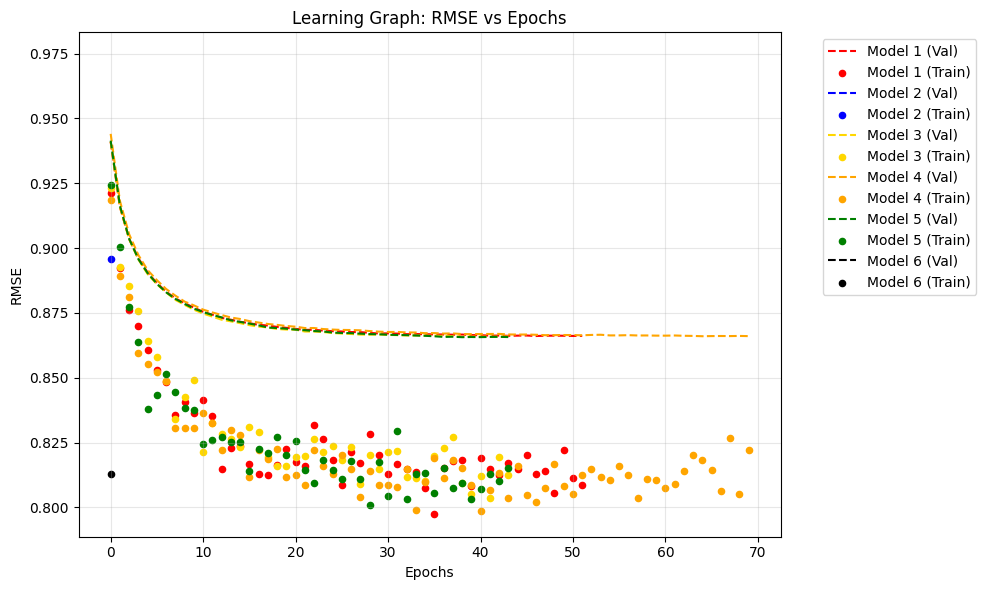

In [57]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Helper to plot with matching lengths to avoid errors
def plot_model(ax, t_rmse, v_rmse, label, color):
    epochs = range(len(v_rmse))
    # Line for Validation RMSE
    ax.plot(epochs, v_rmse, label=f'{label} (Val)', color=color, linestyle='--')
    # Points/Scatter for Training RMSE
    ax.scatter(epochs, t_rmse, label=f'{label} (Train)', color=color, s=20)

# Plotting each model
# Note: Ensure these lists exist. For Model 2, it might just be a single point.
plot_model(ax, t_rmse1, v_rmse1, "Model 1", 'red')

if len(v_rmse2) > 0: # Check if Model 2 has data
    plot_model(ax, t_rmse2, v_rmse2, "Model 2", 'blue')

plot_model(ax, t_rmse3, v_rmse3, "Model 3", 'gold')
plot_model(ax, t_rmse4, v_rmse4, "Model 4", 'orange')
plot_model(ax, t_rmse5, v_rmse5, "Model 5", 'green')
plot_model(ax, t_rmse6, v_rmse6, "Model 6", 'black')

# Formatting
ax.set_title("Learning Graph: RMSE vs Epochs")
ax.set_xlabel("Epochs")
ax.set_ylabel("RMSE")

# Place legend outside so it doesn't cover the lines
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png') # Best for saving in notebook
plt.show()

In [58]:
import numpy as np
from datetime import datetime

print("🚀 Starting export to try.md...")

# A helper to write directly to the file handle to save RAM
def write_matrix(f, name, arr):
    if arr is not None:
        f.write(f"### {name}\n```python\n")
        f.write(f"{name} = np.array(")
        # We use a loop-based string conversion if the matrix is gargantuan, 
        # but np.array2string with threshold=np.inf is usually okay for RAM if written immediately.
        f.write(np.array2string(arr, threshold=np.inf, separator=', '))
        f.write(")\n```\n\n")

with open("try.md", "w") as f:
    # --- Header ---
    f.write(f"# Final 6-Model Recommender Report\n**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")

    # --- Model 1 ---
    print("Writing Model 1...")
    f.write(f"## Model 1: Pure SVD\n- Alpha: {alpha1}\n- Lambda: {lbda1}\n")
    f.write(f"- Train RMSE: {t_rmse1[-1]:.4f} | Val RMSE: {v_rmse1[-1]:.4f}\n\n")
    write_matrix(f, "X_u1", X_u1)
    write_matrix(f, "X_m1", X_m1)
    write_matrix(f, "b_m1", b_m1)
    write_matrix(f, "b_u1", b_u1)
    f.write("---\n")

    # --- Model 2 ---
    print("Writing Model 2...")
    f.write(f"## Model 2: Cosine Similarity\n- Train RMSE: {t_rmse2[-1]:.4f} | Val RMSE: {v_rmse2[-1]:.4f}\n\n---\n")

    # --- Model 3 ---
    print("Writing Model 3...")
    f.write(f"## Model 3: SVD + Genre\n- Alpha: {alpha3}\n- Lambda: {lbda3}\n")
    f.write(f"- Train RMSE: {t_rmse3[-1]:.4f} | Val RMSE: {v_rmse3[-1]:.4f}\n\n")
    write_matrix(f, "X_u3", X_u3)
    write_matrix(f, "X_m3", X_m3)
    write_matrix(f, "X_g3", X_g)
    write_matrix(f, "b_m3", b_m3)
    write_matrix(f, "X_m1", b_u3)
    f.write("---\n")

    # --- Model 4 ---
    print("Writing Model 4...")
    f.write(f"## Model 4: SVD + Cosine Similarity\n- Alpha: {alpha4}\n- Lambda: {lbda4}\n")
    f.write(f"- Train RMSE: {t_rmse4[-1]:.4f} | Val RMSE: {v_rmse4[-1]:.4f}\n\n")
    write_matrix(f, "X_u4", X_u4)
    write_matrix(f, "X_m4", X_m4)
    write_matrix(f, "b_m4", b_m4)
    write_matrix(f, "b_u4", b_u4)
    f.write("---\n")

    # --- Model 5 ---
    print("Writing Model 5...")
    f.write(f"## Model 5: Complete Hybrid\n- Alpha: {alpha5}\n- Lambda: {lbda5}\n")
    f.write(f"- Train RMSE: {t_rmse5[-1]:.4f} | Val RMSE: {v_rmse5[-1]:.4f}\n\n")
    write_matrix(f, "X_u5", X_u5)
    write_matrix(f, "X_m5", X_m5)
    write_matrix(f, "X_g5", X_g5)
    write_matrix(f, "b_m5", b_m5)
    write_matrix(f, "b_u5", b_u5)
    f.write("---\n")

    # --- Model 6 ---
    print("Writing Model 6...")
    f.write(f"## Model 6: Ensemble\n")
    f.write(f"- Betas: β1={beta_1}, β2={beta_2}, β3={beta_3}, β4={beta_4}, β5={beta_5}\n")
    f.write(f"- Train RMSE: {t_rmse6[-1]:.4f} | Val RMSE: {v_rmse6[-1]:.4f}\n")

print("✅ Success! try.md created in /kaggle/working/")

🚀 Starting export to try.md...
Writing Model 1...
Writing Model 2...
Writing Model 3...
Writing Model 4...
Writing Model 5...
Writing Model 6...
✅ Success! try.md created in /kaggle/working/


In [59]:
def recommend_movies_for_user(original_user_id, num_recommendations=5):
    # Convert real ID to encoded ID
    u_enc = ue.transform([original_user_id])[0]
    
    # Get movies the user hasn't seen
    seen_movies = set(df[df['userId'] == original_user_id]['movieId'])
    all_movies = set(me.classes_)
    unseen_movies = list(all_movies - seen_movies)
    m_enc_list = me.transform(unseen_movies)
    
    predictions = []
    for m_enc in m_enc_list:
        # Using Model 6 (Ensemble) for best accuracy
        pred = evaluate_model(np.array([m_enc]), np.array([u_enc]), np.array([0]), model_type=6)
        predictions.append((m_enc, pred))
    
    # Sort and get top N
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions[:num_recommendations]
    
    print(f"\n--- Top {num_recommendations} Recommendations for User {original_user_id} ---")
    for m_enc, score in top_n:
        real_m_id = me.inverse_transform([m_enc])[0]
        title = movies[movies['movieId'] == real_m_id]['title'].values[0]
        print(f"🎬 {title} (Predicted Score: {score:.2f})")
    


In [60]:
recommend_movies_for_user(df['userId'].iloc[0])


--- Top 5 Recommendations for User 1 ---
🎬 Fireworks (Hana-bi) (1997) (Predicted Score: 4.49)
🎬 Nausicaä of the Valley of the Wind (Kaze no tani no Naushika) (1984) (Predicted Score: 4.43)
🎬 Grand Illusion (La grande illusion) (1937) (Predicted Score: 4.42)
🎬 Celebration, The (Festen) (1998) (Predicted Score: 4.38)
🎬 Before the Rain (Pred dozhdot) (1994) (Predicted Score: 4.33)
